In [1]:
import numpy as np
import matplotlib.pyplot as plt

#the total number of samples sampled per duration
sample_rate = 1000 
duration = 1.0

#the total no of samples 
N = int(sample_rate * duration)

#time index 0 to 999
n = np.arange(N)

#time representation per chunk x axis
#[0/1000,1/1000,2/1000....999/1000]
time = n/sample_rate

signal = (
    1.0 * np.sin(2 * np.pi * 5 * time)
    + 0.5 * np.sin(2 * np.pi * 12 * time)
)

#frequency bin spacing = fs/N = 1000/1000 = 1Hz, hence one fft bin for every 1Hz


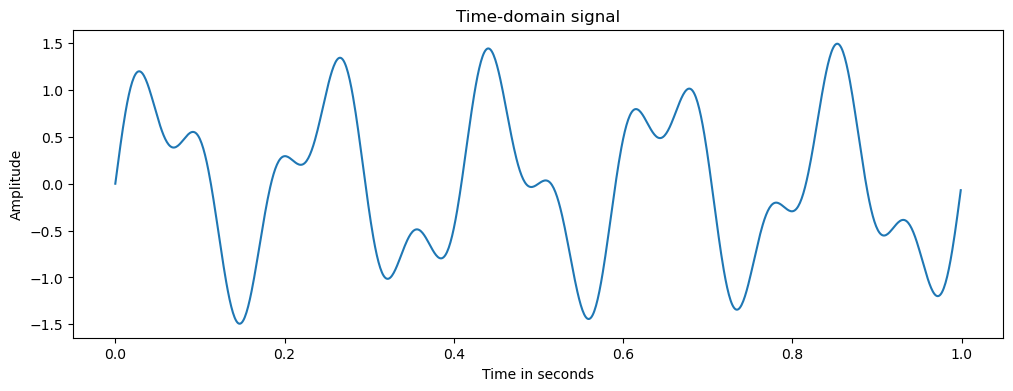

In [2]:
plt.figure(figsize=(12, 4))

plt.plot(time, signal)

plt.xlabel("Time in seconds")
plt.ylabel("Amplitude")
plt.title("Time-domain signal")

plt.show()

In [3]:
#calculating the fft using numpy
#spectrum contains \(N\) complex Fourier coefficients: X[0],X[1],X[2],...X[N-1]
spectrum = np.fft.fft(signal)
print(len(spectrum))

1000


In [4]:
#proof that each value is complex
print(spectrum[5])

(-4.686185362954732e-13-500j)


In [5]:
#generating the frequency values
#The FFT output gives coefficients, but we also need to know which frequency belongs to each coefficient.

frequencies = np.fft.fftfreq(N, d = 1/sample_rate)
"""
where d = time spacing between adjancent samples d = sample_interval = 0.001 seconds

The freq array is arranged approx as : [0, 1, 2, ..., 499, -500, -499, ..., -2, -1]
"""

In [8]:
frequencies[500]

np.float64(-500.0)

In [9]:
spectrum[500]

np.complex128(-5.368329425064647e-15+1.416666606723931e-16j)

In [ ]:
#so freq associated with complex coefficient spectrum[500] is -500Hz

In [10]:
magnitude = np.abs(spectrum)

In [11]:
#tells us raw magnitude of freq stored at frequencies[k]
magnitude[500]

np.float64(5.3701983444525564e-15)

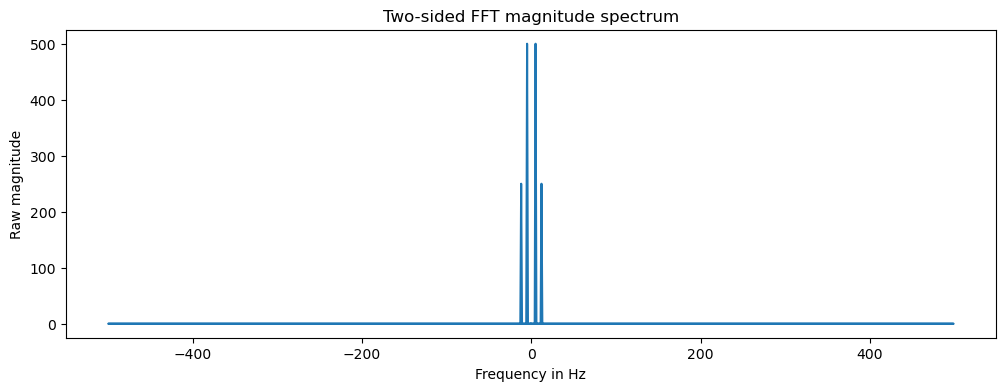

In [12]:
#plotting the complete magnitude spectrum
plt.figure(figsize=(12, 4))

plt.plot(frequencies, magnitude)

plt.xlabel("Frequency in Hz")
plt.ylabel("Raw magnitude")
plt.title("Two-sided FFT magnitude spectrum")

plt.show()

In [ ]:
"""
9. Why do we usually plot only half?
For real-valued signals, the negative-frequency half contains mirrored information.
Therefore, we usually plot only frequencies from: 0hz to fs/2 hz(nyquist freq)

now since its mirrored representation we only concern with either by default positive
"""

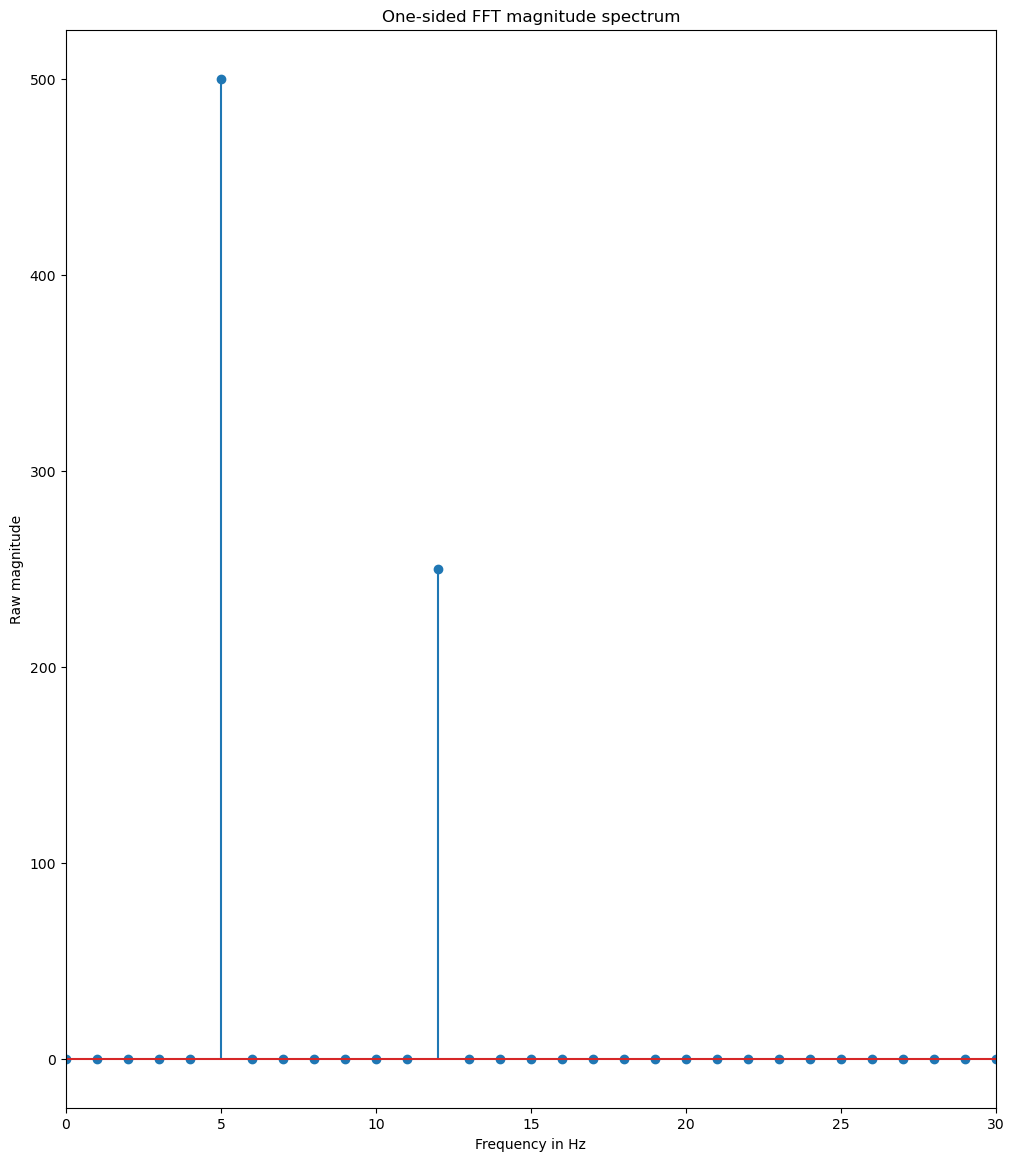

In [14]:
half = N//2

positive_frequencies = frequencies[:half]
positive_magnitude = magnitude[:half]

#plotting the half magnitude spectrum
plt.figure(figsize = (12,14))
plt.stem(positive_frequencies,positive_magnitude)
plt.xlabel("Frequency in Hz")
plt.ylabel("Raw magnitude")
plt.title("One-sided FFT magnitude spectrum")

plt.xlim(0, 30)

plt.show()

In [17]:
"""
11. Why is the magnitude not equal to the original amplitude?
The signal amplitudes are:
A_1=1
and:
A_2=0.5 
But the raw FFT peaks will be approximately:500
and: 250
This happens because the raw DFT magnitude scales with the number of samples.
For a sinusoid that fits exactly into an FFT bin:
|X[k]| approx = A*N//2

For the 5 Hz component:
|X[5]| = A * N/2 = 1 * 1000/2 = 500

For the 12 Hz component:
|X[12]| = 0.5 * 1000/2 = 250
hence we need to resacle the amplitude
A = (2 * X12) / N 
"""

'\n11. Why is the magnitude not equal to the original amplitude?\nThe signal amplitudes are:\nA_1=1\nand:\nA_2=0.5 \nBut the raw FFT peaks will be approximately:500\nand: 250\nThis happens because the raw DFT magnitude scales with the number of samples.\nFor a sinusoid that fits exactly into an FFT bin:\n|X[k]| approx = A*N//2\n\nFor the 5 Hz component:\n|X[5]| = A * N/2 = 1 * 1000/2 = 500\n\nFor the 12 Hz component:\n|X[12]| = 0.5 * 1000/2 = 250\nhence we need to resacle the amplitude\n'

In [19]:
one_sided_amplitude = (
    2 * magnitude[:half] / N
)
[values upto last positive value index]

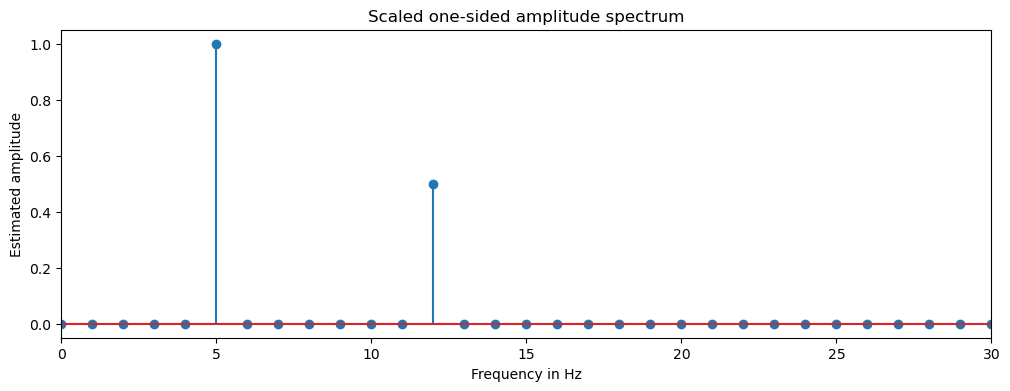

In [20]:
plt.figure(figsize=(12, 4))

plt.stem(
    positive_frequencies,
    one_sided_amplitude
)

plt.xlabel("Frequency in Hz")
plt.ylabel("Estimated amplitude")
plt.title("Scaled one-sided amplitude spectrum")

plt.xlim(0, 30)

plt.show()

In [24]:
#A clearner numpy approach for real signals we can use a numpy method to calculate spectrum
spectrum = np.fft.rfft(signal)
len(spectrum)

501

In [25]:
#Get the matching frequencies using:
frequencies = np.fft.rfftfreq(
    N,
    d=1 / sample_rate
)
print(len(frequencies))

501


In [26]:
frequencies

array([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,
        11.,  12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,
        22.,  23.,  24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,
        33.,  34.,  35.,  36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,
        44.,  45.,  46.,  47.,  48.,  49.,  50.,  51.,  52.,  53.,  54.,
        55.,  56.,  57.,  58.,  59.,  60.,  61.,  62.,  63.,  64.,  65.,
        66.,  67.,  68.,  69.,  70.,  71.,  72.,  73.,  74.,  75.,  76.,
        77.,  78.,  79.,  80.,  81.,  82.,  83.,  84.,  85.,  86.,  87.,
        88.,  89.,  90.,  91.,  92.,  93.,  94.,  95.,  96.,  97.,  98.,
        99., 100., 101., 102., 103., 104., 105., 106., 107., 108., 109.,
       110., 111., 112., 113., 114., 115., 116., 117., 118., 119., 120.,
       121., 122., 123., 124., 125., 126., 127., 128., 129., 130., 131.,
       132., 133., 134., 135., 136., 137., 138., 139., 140., 141., 142.,
       143., 144., 145., 146., 147., 148., 149., 15

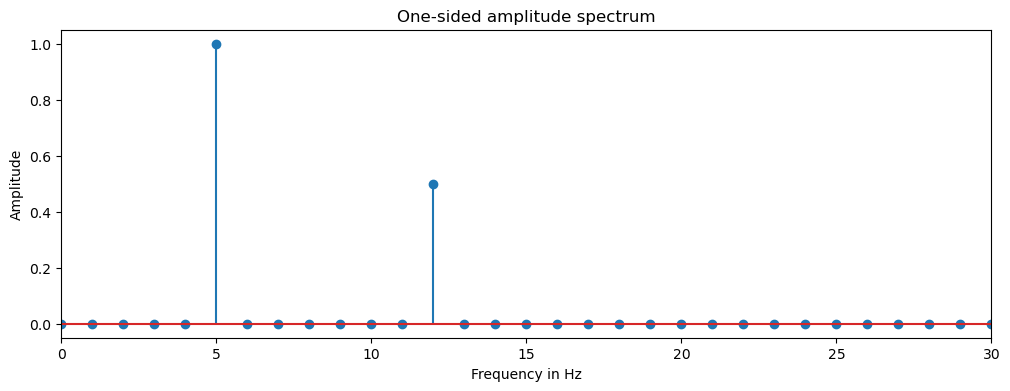

In [27]:
import numpy as np
import matplotlib.pyplot as plt

sample_rate = 1000
duration = 1.0

N = int(sample_rate * duration)

n = np.arange(N)
time = n / sample_rate

signal = (
    np.sin(2 * np.pi * 5 * time)
    + 0.5 * np.sin(2 * np.pi * 12 * time)
)

spectrum = np.fft.rfft(signal)

frequencies = np.fft.rfftfreq(
    N,
    d=1 / sample_rate
)

amplitude_spectrum = np.abs(spectrum) / N

amplitude_spectrum[1:-1] *= 2 #multiply every value by 2 as per formula \X[k]| = A*N//2

plt.figure(figsize=(12, 4))

plt.stem(
    frequencies,
    amplitude_spectrum
)

plt.xlabel("Frequency in Hz")
plt.ylabel("Amplitude")
plt.title("One-sided amplitude spectrum")

plt.xlim(0, 30)

plt.show()

In [ ]:
"""
17. What does each array mean?
signal
signal[n]
Amplitude at sample index n.
spectrum
spectrum[k]
Complex Fourier coefficient for frequency bin k.
frequencies
frequencies[k]
Actual frequency in hertz represented by bin k.
np.abs(spectrum)
magnitude[k]
Magnitude of the complex coefficient at bin k.
np.angle(spectrum)
phase[k]
Phase angle of the coefficient at bin k.
"""

In [29]:
#inspecting largest freq families 
largest_bins = np.argsort(
    amplitude_spectrum
)[-5:]
#these are the bins where amp is the highest arsort sorts and returns the top 5 which are from values from the right end
largest_bins

array([ 3,  4, 13, 12,  5])

In [30]:
for k in largest_bins:
    print(
        "Bin:",
        k,
        "Frequency:",
        frequencies[k],
        "Amplitude:",
        amplitude_spectrum[k]
    )

Bin: 3 Frequency: 3.0 Amplitude: 3.5765259022185843e-16
Bin: 4 Frequency: 4.0 Amplitude: 5.398279147229949e-16
Bin: 13 Frequency: 13.0 Amplitude: 5.869467127895631e-16
Bin: 12 Frequency: 12.0 Amplitude: 0.5000000000000001
Bin: 5 Frequency: 5.0 Amplitude: 1.0
